# Molecular Weight & Heavy Atom Distribution Analysis (35327 Compounds)
## Environment Guide
This notebook supports any Python environment with required packages installed.
Install dependencies as preferred via Conda, uv, pip or other package managers.
Required libraries: polars, pandas, rdkit, matplotlib, seaborn
Launch Jupyter Lab under your own configured virtual environment.

### File I/O
Input: paper_35327_samples.parquet
Output: molecular_properties.csv, distribution figures


Total input samples: 35,327
Successfully parsed molecules: 35,327
Failed to parse SMILES entries: 0

Molecular Weight Statistics (Da)
--------------------------------------------------
count    35327.00
mean       209.31
std        114.13
min         16.04
25%        148.68
50%        188.34
75%        242.24
max       5793.64
Name: molecular_weight, dtype: float64

Heavy Atom Count Statistics
--------------------------------------------------
count    35327
mean        14
std          8
min          1
25%         10
50%         12
75%         16
max        404
Name: heavy_atom_count, dtype: int64


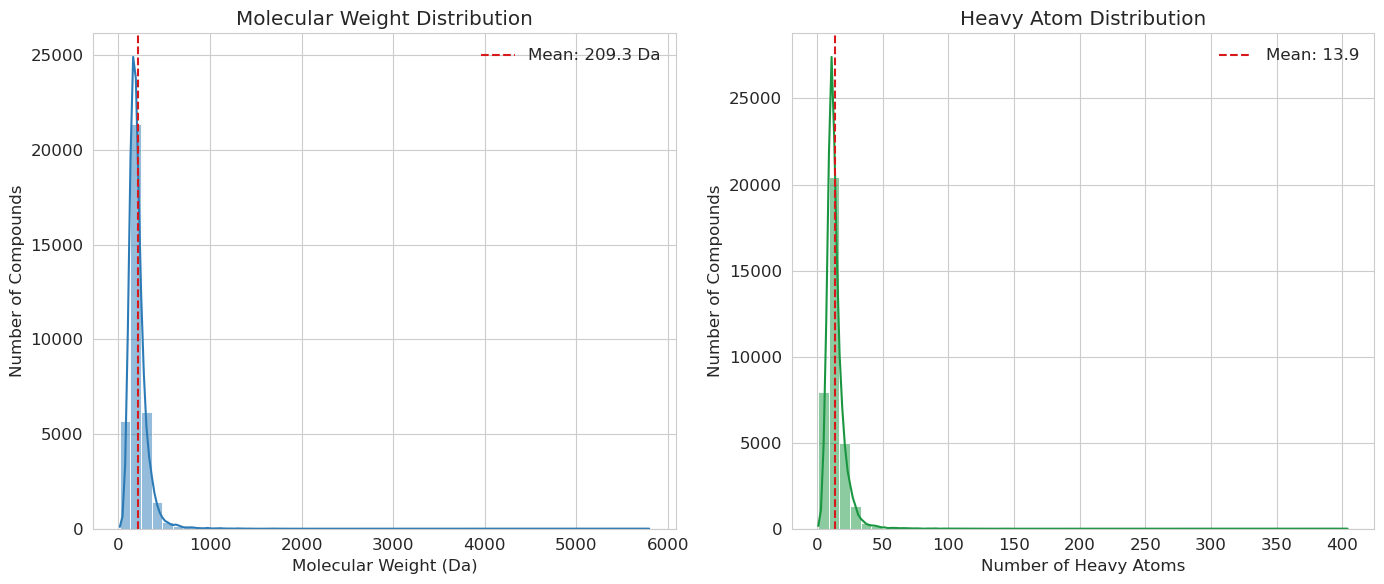

In [ ]:
import polars as pl
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
import seaborn as sns

# Load curated dataset matching the paper data scale
df = pl.read_parquet("./paper_35327_samples.parquet").to_pandas()
print(f"Total input samples: {len(df):,}")

def calc_mol_props(smiles: str):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None, None
        mol_weight = Descriptors.MolWt(mol)
        heavy_atom = Descriptors.HeavyAtomCount(mol)
        return mol_weight, heavy_atom
    except Exception:
        return None, None

# Batch calculate molecular descriptors
df[["molecular_weight", "heavy_atom_count"]] = df["smiles"].apply(
    lambda x: pd.Series(calc_mol_props(x))
)

# Filter out molecules with unparseable SMILES
valid_df = df.dropna(subset=["molecular_weight", "heavy_atom_count"])
total_input = len(df)
valid_count = len(valid_df)
fail_count = total_input - valid_count
print(f"Successfully parsed molecules: {valid_count:,}")
print(f"Failed to parse SMILES entries: {fail_count}")

# Print statistical summary
print("\n" + "=" * 50)
print("Molecular Weight Statistics (Da)")
print("-" * 50)
print(valid_df["molecular_weight"].describe().round(2))

print("\n" + "=" * 50)
print("Heavy Atom Count Statistics")
print("-" * 50)
print(valid_df["heavy_atom_count"].describe().round(0).astype(int))

# Global plotting style configuration
sns.set_style("whitegrid")
plt.rcParams["font.size"] = 12

# Initialize dual subplot canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot molecular weight distribution with KDE
sns.histplot(
    data=valid_df,
    x="molecular_weight",
    bins=50,
    kde=True,
    ax=ax1,
    color="#2c7bb6",
    edgecolor="white"
)
mean_mw = valid_df["molecular_weight"].mean()
ax1.set_xlabel("Molecular Weight (Da)")
ax1.set_ylabel("Number of Compounds")
ax1.set_title("Molecular Weight Distribution")
ax1.axvline(mean_mw, color="#d7191c", linestyle="--", linewidth=1.5, label=f"Mean: {mean_mw:.1f} Da")
ax1.legend(frameon=False)

# Plot heavy atom count distribution with KDE
sns.histplot(
    data=valid_df,
    x="heavy_atom_count",
    bins=50,
    kde=True,
    ax=ax2,
    color="#1a9641",
    edgecolor="white"
)
mean_ha = valid_df["heavy_atom_count"].mean()
ax2.set_xlabel("Number of Heavy Atoms")
ax2.set_ylabel("Number of Compounds")
ax2.set_title("Heavy Atom Distribution")
ax2.axvline(mean_ha, color="#d7191c", linestyle="--", linewidth=1.5, label=f"Mean: {mean_ha:.1f}")
ax2.legend(frameon=False)

plt.tight_layout()
# plt.savefig("mol_weight_heavy_atom_dist.png", dpi=300, bbox_inches="tight")
plt.show()

# Export full molecular descriptor table for further analysis
output_columns = ["sample_id", "smiles", "molecular_weight", "heavy_atom_count"]
# valid_df[output_columns].to_csv("molecular_properties.csv", index=False)


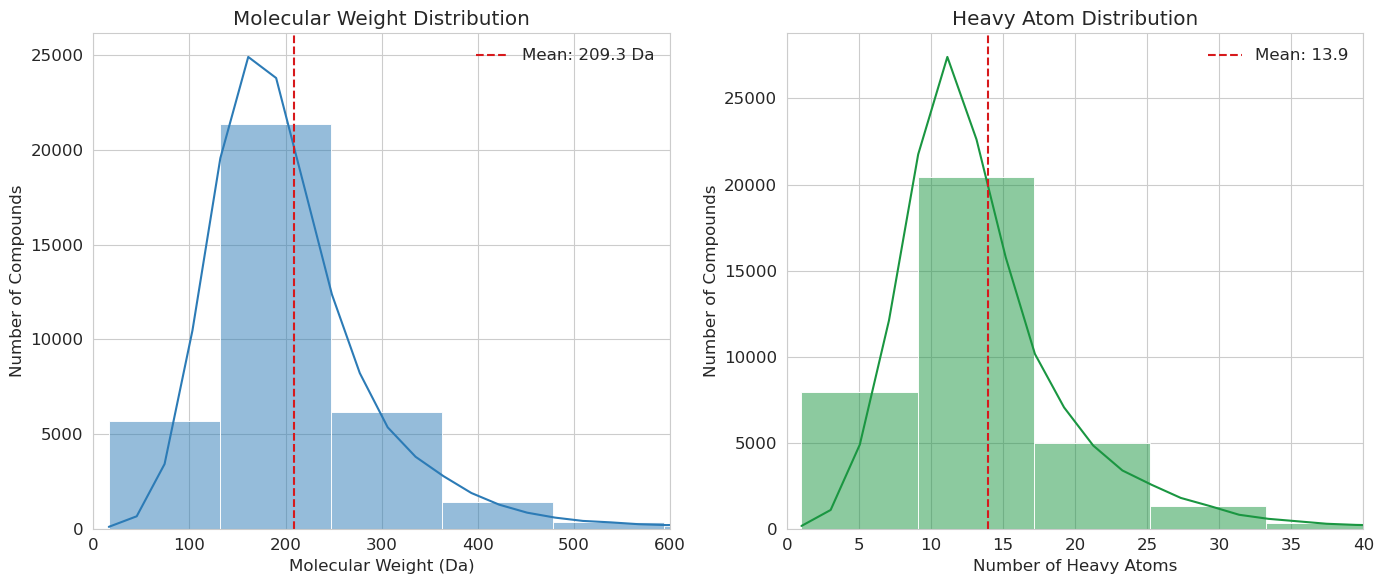

In [ ]:
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot molecular weight distribution, limit x-axis to 0-600 Da to focus on main population
sns.histplot(
    data=valid_df,
    x="molecular_weight",
    bins=50,
    kde=True,
    ax=ax1,
    color="#2c7bb6",
    edgecolor="white"
)
ax1.set_xlim(left=0, right=600)
ax1.set_xlabel("Molecular Weight (Da)")
ax1.set_ylabel("Number of Compounds")
ax1.set_title("Molecular Weight Distribution")
mean_mw = valid_df["molecular_weight"].mean()
ax1.axvline(mean_mw, color="#d7191c", linestyle="--", linewidth=1.5, label=f"Mean: {mean_mw:.1f} Da")
ax1.legend(frameon=False)

# Plot heavy atom count distribution, limit x-axis to 0-40 to exclude extreme outliers
sns.histplot(
    data=valid_df,
    x="heavy_atom_count",
    bins=50,
    kde=True,
    ax=ax2,
    color="#1a9641",
    edgecolor="white"
)
ax2.set_xlim(left=0, right=40)
ax2.set_xlabel("Number of Heavy Atoms")
ax2.set_ylabel("Number of Compounds")
ax2.set_title("Heavy Atom Distribution")
mean_ha = valid_df["heavy_atom_count"].mean()
ax2.axvline(mean_ha, color="#d7191c", linestyle="--", linewidth=1.5, label=f"Mean: {mean_ha:.1f}")
ax2.legend(frameon=False)

plt.tight_layout()
# plt.savefig("fig2_mol_property_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
